# Fraud Detection — 02. Моделирование и тюнинг
# Fraud Detection — 02. Modeling & Tuning

Берём готовые признаки из `data/processed/*.parquet` (ноутбук 01): baseline по 4
алгоритмам, затем тюнинг 3 GBM (Optuna) и сохранение моделей. Сабмишн — в ноутбуке 03.

We take the prepared features from `data/processed/*.parquet` (notebook 01): a baseline of
4 algorithms, then tuning of 3 GBMs (Optuna) and saving the models. Submission is in
notebook 03.

## Настройка / Setup

In [1]:
import gc, os, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import rankdata

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, precision_recall_curve, precision_score,
                             recall_score, f1_score, confusion_matrix)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS = 30
pd.set_option("display.max_columns", 100)

/home/mchunikhin/miniconda3/envs/fraud/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Устройства для моделей / Devices for the models
LGB_DEVICE = "cpu"
XGB_DEVICE = "cuda"
CAT_TASK = "GPU"
print("LightGBM:", LGB_DEVICE, "| XGBoost:", XGB_DEVICE, "| CatBoost:", CAT_TASK)

LightGBM: cpu | XGBoost: cuda | CatBoost: GPU


### Замечание про устройства (GPU) / Note on devices (GPU)

LightGBM считаем на CPU. Мы пробовали обучать его на GPU (CUDA-сборка), но на наших данных
качество заметно падало (≈0.84 против ≈0.94): CUDA-движок LightGBM плохо обрабатывает
пропуски (NaN) и разреженные признаки, а их в данных много. XGBoost и CatBoost на GPU
работают корректно — их оставляем на видеокарте.

We run LightGBM on CPU. We tried training it on GPU (the CUDA build), but on our data the
quality dropped noticeably (≈0.84 vs ≈0.94): LightGBM's CUDA engine handles missing values
(NaN) and sparse features poorly, and our data has many of them. XGBoost and CatBoost work
correctly on GPU, so we keep them on the GPU.

## Загрузка данных / Load processed data

Читаем parquet и разделяем признаки `X` и цель `y`. Тестовая выборка тут не нужна — она в
ноутбуке 03.

We read the parquet and split features `X` from target `y`. The test set is not needed
here — it is used in notebook 03.

In [3]:
def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "processed" / "train.parquet").exists():
            return base
    return None

PROJECT_ROOT = find_project_root()
assert PROJECT_ROOT is not None, "Не найден data/processed/train.parquet — сначала запусти ноутбук 01."
PROCESSED_DIR = str(PROJECT_ROOT / "data" / "processed")
MODELS_DIR = str(PROJECT_ROOT / "models")
os.makedirs(MODELS_DIR, exist_ok=True)

train = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
X = train.drop(columns=["isFraud"])
y = train["isFraud"]
print(f"X: {X.shape} | fraud rate: {y.mean()*100:.2f}%")

X: (590537, 471) | fraud rate: 3.50%


## Стратегия валидации / Validation Strategy

Транзакции идут по возрастанию времени, а тест соревнования — это будущее. Случайный
K-Fold перемешивает прошлое и будущее и завышает оценку. Честнее — time-aware holdout:
учимся на ранних транзакциях, проверяем на поздних (последние 20%).

Transactions are ordered by time, and the competition test set is the future. A random
K-Fold mixes past and future and overstates the score. A time-aware holdout is more honest:
train on earlier transactions, validate on later ones (the last 20%).

In [4]:
train_sorted = train.sort_values("TransactionDT")
y_sorted = train_sorted["isFraud"]
X_sorted = train_sorted.drop(columns=["isFraud"])

valid_size = int(len(train_sorted) * 0.2)
X_tr, X_val = X_sorted.iloc[:-valid_size], X_sorted.iloc[-valid_size:]
y_tr, y_val = y_sorted.iloc[:-valid_size], y_sorted.iloc[-valid_size:]
print(f"train: {X_tr.shape} | valid: {X_val.shape}")

train: (472430, 471) | valid: (118107, 471)


## Baseline-модели / Baseline Models

Обучаем 4 модели с настройками по умолчанию на одном time-aware сплите, чтобы честно
сравнить алгоритмы до тюнинга. Метрика — ROC-AUC.

We train 4 models with default settings on the same time-aware split, to compare the
algorithms fairly before tuning. The metric is ROC-AUC.

In [5]:
results = []
def record(name, auc, secs, device):
    results.append({"Model": name, "ROC-AUC": round(auc, 5), "fit_s": round(secs, 1), "device": device})
    print(f"{name:20s} ROC-AUC={auc:.5f}  ({secs:.1f}s, {device})")

In [6]:
# Логистическая регрессия — нижняя планка (нужны заполнение пропусков и масштабирование)
# Logistic Regression — the floor (needs NaN fill and scaling)
scaler = StandardScaler()
X_tr_lr = scaler.fit_transform(X_tr.fillna(0))
X_val_lr = scaler.transform(X_val.fillna(0))
t0 = time.time()
lr = LogisticRegression(max_iter=200, n_jobs=-1, random_state=RANDOM_STATE)
lr.fit(X_tr_lr, y_tr)
auc = roc_auc_score(y_val, lr.predict_proba(X_val_lr)[:, 1])
record("LogisticRegression", auc, time.time() - t0, "CPU")
del X_tr_lr, X_val_lr; gc.collect()

LogisticRegression   ROC-AUC=0.81995  (50.3s, CPU)


52

In [7]:
# LightGBM baseline
t0 = time.time()
lgb_base = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=64,
                              random_state=RANDOM_STATE, device=LGB_DEVICE, verbosity=-1)
lgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc",
             callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
auc = roc_auc_score(y_val, lgb_base.predict_proba(X_val)[:, 1])
record("LightGBM", auc, time.time() - t0, LGB_DEVICE)

LightGBM             ROC-AUC=0.92463  (33.8s, cpu)


In [8]:
# XGBoost baseline
t0 = time.time()
xgb_base = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=8,
                             tree_method="hist", device=XGB_DEVICE, random_state=RANDOM_STATE,
                             eval_metric="auc", early_stopping_rounds=50)
xgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
auc = roc_auc_score(y_val, xgb_base.predict_proba(X_val)[:, 1])
record("XGBoost", auc, time.time() - t0, XGB_DEVICE)

XGBoost              ROC-AUC=0.92631  (26.5s, cuda)


In [9]:
# CatBoost baseline
t0 = time.time()
cat_base = cb.CatBoostClassifier(iterations=500, learning_rate=0.05, depth=8,
                                 eval_metric="AUC", random_seed=RANDOM_STATE,
                                 task_type=CAT_TASK, verbose=False, early_stopping_rounds=50)
cat_base.fit(X_tr, y_tr, eval_set=(X_val, y_val))
auc = roc_auc_score(y_val, cat_base.predict_proba(X_val)[:, 1])
record("CatBoost", auc, time.time() - t0, CAT_TASK)

Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost             ROC-AUC=0.89900  (15.7s, GPU)


In [10]:
baseline_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
base_auc = {r["Model"]: r["ROC-AUC"] for r in results}
baseline_df

,Model,ROC-AUC,fit_s,device
0,XGBoost,0.92631,26.5,cuda
1,LightGBM,0.92463,33.8,cpu
2,CatBoost,0.89900,15.7,GPU
3,LogisticRegression,0.81995,50.3,CPU


### Вывод

Три GBM-модели заметно превосходят логистическую регрессию: XGBoost (0.92631), LightGBM
(0.92463) и CatBoost (0.89628) против 0.81995 у логистической регрессии. Разрыв подтверждает,
что зависимости в данных нелинейные. Логистическую регрессию мы используем только как опорный
ориентир и дальше не настраиваем, а три GBM отправляем на подбор гиперпараметров.

### Summary

The three GBM models clearly outperform logistic regression: XGBoost (0.92631), LightGBM
(0.92463) and CatBoost (0.89628) versus 0.81995 for logistic regression. The gap confirms that
the relationships in the data are non-linear. We keep logistic regression only as a reference
baseline and do not tune it further, while the three GBMs go to hyperparameter tuning.

## Подбор гиперпараметров / Hyperparameter Tuning

Подбираем гиперпараметры трёх GBM одинаково: тот же time-aware сплит, одинаковый бюджет
(30 итераций) и метод оптимизации Optuna (TPE). Диапазоны поиска узкие — вокруг разумных
значений (вариант с низкой скоростью обучения, большим запасом деревьев и ранней остановкой).
После каждой итерации выводим её результат, а в конце строим график. Результаты сохраняются в
SQLite (`models/optuna_*.db`), поэтому при повторном запуске подбор **продолжается только для
недостающих** итераций, а не считается заново.

## Hyperparameter Tuning

We tune the three GBMs in the same way: the same time-aware split, the same budget
(30 iterations) and the Optuna (TPE) optimisation method. The search ranges are narrow —
around sensible values (a variant with a low learning rate, a large tree budget and early
stopping). After each iteration we print its result, and at the end we draw a chart. The
results are stored in SQLite (`models/optuna_*.db`), so on a re-run the search **only
continues the missing** iterations instead of recomputing everything.

In [11]:
# После каждой пробы печатаем результат / Print the result after each trial
def log_trial(study, trial):
    print(f"  trial {trial.number:2d}: ROC-AUC = {trial.value:.5f}   (best {study.best_value:.5f})")

# Создаём/продолжаем study и догоняем недостающие trials
# Create/resume a study and top up the missing trials
def tune(name, objective):
    study = optuna.create_study(
        direction="maximize", study_name=name, load_if_exists=True,
        storage=f"sqlite:///{os.path.join(MODELS_DIR, f'optuna_{name}.db')}",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True))
    done = sum(t.state.name == "COMPLETE" for t in study.trials)
    remaining = max(0, N_TRIALS - done)
    print(f"{name}: {done}/{N_TRIALS} готово, запускаю ещё {remaining}")
    if remaining:
        study.optimize(objective, n_trials=remaining, callbacks=[log_trial])
    print(f"{name} best ROC-AUC: {study.best_value:.5f}")
    return study

In [12]:
def lgb_objective(trial):
    params = dict(
        objective="binary", metric="auc", boosting_type="gbdt",
        n_estimators=2000, device=LGB_DEVICE, random_state=RANDOM_STATE, verbosity=-1,
        subsample_freq=1,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.03, log=True),
        num_leaves=trial.suggest_int("num_leaves", 128, 300),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 0.8),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 60),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
    )
    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc",
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

study_lgb = tune("lgb", lgb_objective)

lgb: 31/30 готово, запускаю ещё 0
lgb best ROC-AUC: 0.93797


In [13]:
def xgb_objective(trial):
    params = dict(
        n_estimators=2000, tree_method="hist", device=XGB_DEVICE,
        random_state=RANDOM_STATE, eval_metric="auc", early_stopping_rounds=100,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        max_depth=trial.suggest_int("max_depth", 5, 11),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 0.8),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 20.0),
        gamma=trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
    )
    m = xgb.XGBClassifier(**params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

study_xgb = tune("xgb", xgb_objective)

xgb: 30/30 готово, запускаю ещё 0
xgb best ROC-AUC: 0.93580


In [14]:
def cat_objective(trial):
    params = dict(
        iterations=2000, task_type=CAT_TASK, eval_metric="AUC",
        random_seed=RANDOM_STATE, verbose=False, early_stopping_rounds=100,
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.08, log=True),
        depth=trial.suggest_int("depth", 6, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        random_strength=trial.suggest_float("random_strength", 0.0, 2.0),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        border_count=trial.suggest_int("border_count", 128, 254),
    )
    m = cb.CatBoostClassifier(**params)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

study_cat = tune("cat", cat_objective)

cat: 30/30 готово, запускаю ещё 0
cat best ROC-AUC: 0.92802


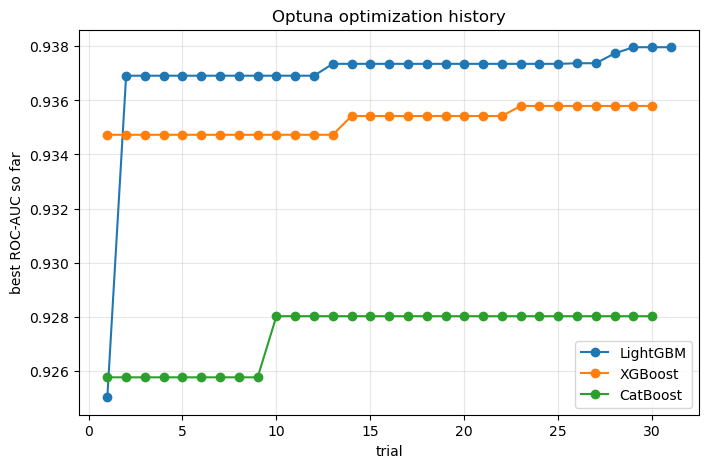

In [15]:
# График хода оптимизации по всем моделям / Optimization history for all models
fig, ax = plt.subplots(figsize=(8, 5))
for name, study in [("LightGBM", study_lgb), ("XGBoost", study_xgb), ("CatBoost", study_cat)]:
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(vals)
    ax.plot(range(1, len(best_so_far) + 1), best_so_far, marker="o", label=name)
ax.set_xlabel("trial")
ax.set_ylabel("best ROC-AUC so far")
ax.set_title("Optuna optimization history")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [16]:
# Сравнение до/после тюнинга + сохранение лучших параметров
# Before/after tuning comparison + save best params
tuned = {"LightGBM": study_lgb.best_value, "XGBoost": study_xgb.best_value, "CatBoost": study_cat.best_value}
cmp = pd.DataFrame({"baseline": {k: base_auc[k] for k in tuned}, "tuned": tuned})
cmp["delta"] = (cmp["tuned"] - cmp["baseline"]).round(5)
cmp = cmp.round(5).sort_values("tuned", ascending=False)

best_params = {"lightgbm": study_lgb.best_params,
               "xgboost":  study_xgb.best_params,
               "catboost": study_cat.best_params}
with open(os.path.join(MODELS_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f, indent=2)
print("best_params.json saved")
cmp

best_params.json saved


,baseline,tuned,delta
LightGBM,0.92463,0.93797,0.01334
XGBoost,0.92631,0.93580,0.00949
CatBoost,0.89900,0.92802,0.02902


### Вывод

После подбора гиперпараметров качество всех трёх моделей градиентного бустинга выросло, а их
итоговые результаты сблизились. Прирост ROC-AUC относительно базовых моделей:

| Модель | Базовая | После подбора | Прирост |
|---|---|---|---|
| LightGBM | 0.92463 | 0.93797 | +0.01334 |
| XGBoost | 0.92631 | 0.93580 | +0.00949 |
| CatBoost | 0.89628 | 0.92802 | +0.03174 |

Сильнее всего выросла CatBoost, поскольку у неё было самое низкое базовое значение. Близость
итоговых результатов указывает на то, что мы приблизились к пределу возможностей одиночной
модели на текущем наборе признаков. Лучшие параметры сохранены в `models/best_params.json`.

### Summary

After hyperparameter tuning the quality of all three gradient boosting models improved, and
their final results converged. ROC-AUC gain over the baseline models:

| Model | Baseline | Tuned | Gain |
|---|---|---|---|
| LightGBM | 0.92463 | 0.93797 | +0.01334 |
| XGBoost | 0.92631 | 0.93580 | +0.00949 |
| CatBoost | 0.89628 | 0.92802 | +0.03174 |

CatBoost improved the most, as it had the lowest baseline. The closeness of the final results
suggests we are near the limit of a single model on the current feature set. The best
parameters are saved to `models/best_params.json`.

## Финальные модели и сохранение / Final models & saving

Обучаем три лучшие модели (LightGBM, XGBoost, CatBoost) с подобранными параметрами и
сохраняем их на диск, чтобы в ноутбуке 03 использовать для предсказаний и чтобы сравнить
их объединение (ансамбль). Если модели уже сохранены — заново не обучаем, а просто загружаем.

Для каждой модели делаем два шага:
1. Сначала обучаем на обучающей части с ранней остановкой — так мы узнаём нужное число
   деревьев и получаем предсказания на отложенной выборке (валидации).
2. Затем обучаем заново на всех данных и сохраняем в `models/*.pkl`.

Предсказания на валидации сохраняем в `models/val_preds.parquet` — они нужны, чтобы
сравнить модели между собой и проверить, помогает ли их объединение.

## Final models & saving

We train the three best models (LightGBM, XGBoost, CatBoost) with the tuned parameters and
save them to disk, so notebook 03 can use them for predictions and so we can compare their
combination (the ensemble). If the models are already saved, we do not retrain — we just load
them.

For each model we do two steps:
1. First we train on the training part with early stopping — this tells us the number of
   trees we need and gives predictions on the held-out (validation) set.
2. Then we retrain on all the data and save to `models/*.pkl`.

We store the validation predictions in `models/val_preds.parquet` — we need them to compare
the models against each other and to check whether combining them helps.

In [17]:
val_path = os.path.join(MODELS_DIR, "val_preds.parquet")
saved = all(os.path.exists(os.path.join(MODELS_DIR, f)) for f in ["lgb.pkl", "xgb.pkl", "cat.pkl"]) and os.path.exists(val_path)

if saved:
    print("Модели и val_preds уже сохранены — пропускаем обучение / already saved, skipping")
    vp = pd.read_parquet(val_path)
    val_preds = {k: vp[k].values for k in ["lgb", "xgb", "cat"]}
else:
    val_preds = {}

    lgb_p = dict(objective="binary", metric="auc", device=LGB_DEVICE, random_state=RANDOM_STATE,
                 verbosity=-1, subsample_freq=1, **study_lgb.best_params)
    m = lgb.LGBMClassifier(n_estimators=2000, **lgb_p)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc",
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    val_preds["lgb"] = m.predict_proba(X_val)[:, 1]
    joblib.dump(lgb.LGBMClassifier(n_estimators=int(m.best_iteration_ * 1.1), **lgb_p).fit(X, y),
                os.path.join(MODELS_DIR, "lgb.pkl"))

    xgb_p = dict(tree_method="hist", device=XGB_DEVICE, random_state=RANDOM_STATE,
                 eval_metric="auc", **study_xgb.best_params)
    m = xgb.XGBClassifier(n_estimators=2000, early_stopping_rounds=100, **xgb_p)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    val_preds["xgb"] = m.predict_proba(X_val)[:, 1]
    joblib.dump(xgb.XGBClassifier(n_estimators=int(m.best_iteration * 1.1), **xgb_p).fit(X, y),
                os.path.join(MODELS_DIR, "xgb.pkl"))

    cat_p = dict(task_type=CAT_TASK, eval_metric="AUC", random_seed=RANDOM_STATE,
                 verbose=False, **study_cat.best_params)
    m = cb.CatBoostClassifier(iterations=2000, early_stopping_rounds=100, **cat_p)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    val_preds["cat"] = m.predict_proba(X_val)[:, 1]
    joblib.dump(cb.CatBoostClassifier(iterations=int(m.get_best_iteration() * 1.1), **cat_p).fit(X, y),
                os.path.join(MODELS_DIR, "cat.pkl"))

    vp = pd.DataFrame(val_preds, index=X_val.index)
    vp["y"] = y_val.values
    vp.to_parquet(val_path)
    print("saved: lgb.pkl, xgb.pkl, cat.pkl, val_preds.parquet")

Модели и val_preds уже сохранены — пропускаем обучение / already saved, skipping


In [18]:
# Сравнение моделей и блендов на валидации / Models and blends on the holdout
vp = pd.read_parquet(val_path)
y_h = vp["y"].values
def blend_auc(cols):
    r = np.mean([rankdata(vp[c]) for c in cols], axis=0)
    return roc_auc_score(y_h, r)

print("Holdout ROC-AUC:")
for k in ["lgb", "xgb", "cat"]:
    print(f"  {k}: {roc_auc_score(y_h, vp[k]):.5f}")
print(f"  blend lgb+xgb+cat: {blend_auc(['lgb', 'xgb', 'cat']):.5f}")
print(f"  blend lgb+xgb:     {blend_auc(['lgb', 'xgb']):.5f}")

Holdout ROC-AUC:
  lgb: 0.93797
  xgb: 0.93580
  cat: 0.92623
  blend lgb+xgb+cat: 0.93721
  blend lgb+xgb:     0.93793


### Вывод

Лучшей одиночной моделью оказалась LightGBM (ROC-AUC 0.93797). Объединение моделей прироста
не даёт:

| Вариант | ROC-AUC на валидации |
|---|---|
| LightGBM | 0.93797 |
| XGBoost | 0.93580 |
| CatBoost | 0.92623 |
| LightGBM + XGBoost | 0.93793 |
| LightGBM + XGBoost + CatBoost | 0.93721 |

Усреднение LightGBM и XGBoost (0.93793) практически совпадает с одной LightGBM, а добавление
CatBoost даже ухудшает результат (0.93721), потому что CatBoost слабее остальных. Эксперименты
на Kaggle показали то же самое, поэтому в качестве итоговой модели мы оставляем одиночную, без
ансамбля.

### Summary

The best single model is LightGBM (ROC-AUC 0.93797). Combining the models gives no
improvement:

| Option | Validation ROC-AUC |
|---|---|
| LightGBM | 0.93797 |
| XGBoost | 0.93580 |
| CatBoost | 0.92623 |
| LightGBM + XGBoost | 0.93793 |
| LightGBM + XGBoost + CatBoost | 0.93721 |

Averaging LightGBM and XGBoost (0.93793) is practically the same as LightGBM alone, and adding
CatBoost even makes it worse (0.93721), because CatBoost is weaker than the others. Experiments
on Kaggle showed the same, so we keep the single model as the final one, without an ensemble.

## Объяснимость — SHAP / Explainability — SHAP

SHAP показывает, какие признаки и как влияют на предсказание модели. Считаем значения SHAP
для лучшей модели (LightGBM) на выборке из валидации и строим сводный график: чем выше
признак, тем сильнее он влияет; цвет — значение признака.

SHAP shows which features drive the model's prediction and how. We compute SHAP values for
the best model (LightGBM) on a sample of the validation set and draw a summary plot: features
higher up matter more; colour encodes the feature value.

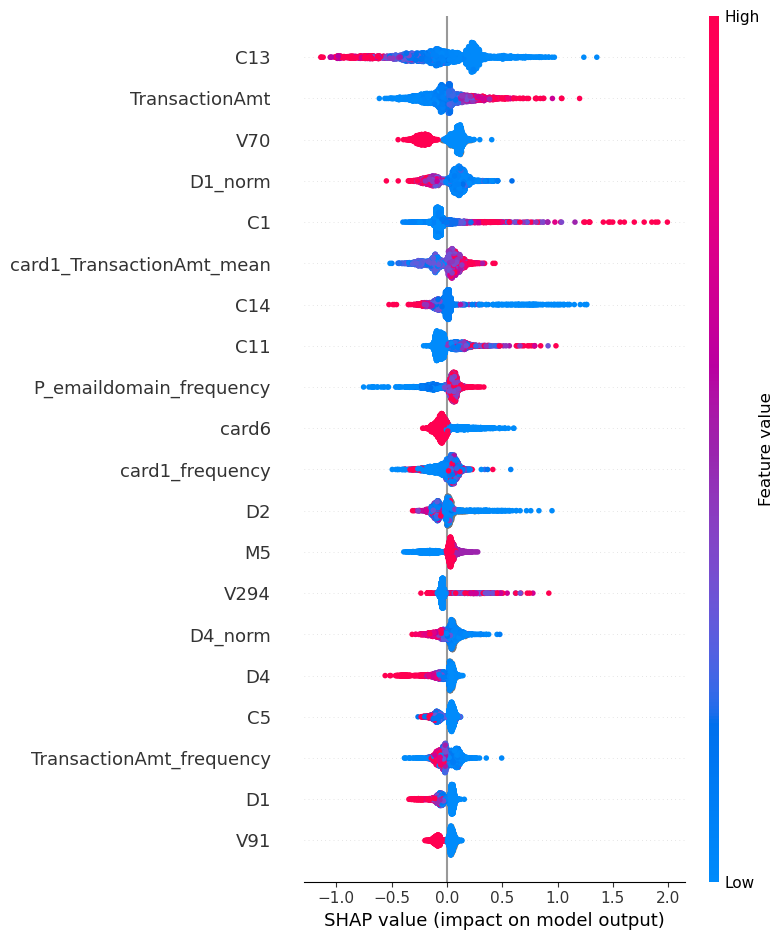

In [19]:
lgb_model = joblib.load(os.path.join(MODELS_DIR, "lgb.pkl"))
sample = X_val.sample(min(3000, len(X_val)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap.summary_plot(shap_values, sample, max_display=20)

### Вывод

Сильнее всего на предсказание влияют:
- **счётчики активности карты/адреса** — `C13`, `C1`, `C14`, `C11`: это, по сути, как часто
  встречается карта или адрес. Большие значения часто связаны с фродом.
- **сумма транзакции** `TransactionAmt` — и наши признаки на её основе
  (`card1_TransactionAmt_mean` — средняя сумма по карте).
- **временные признаки** `D1_norm`, `D2`, `D4`, `D4_norm` — сколько времени прошло с
  прошлой активности карты.
- **частотные признаки**, которые мы сами посчитали в ноутбуке 01
  (`P_emaildomain_frequency`, `card1_frequency`, `TransactionAmt_frequency`) — как часто
  встречается домен почты, карта или сумма.

Важно: придуманные нами признаки (средние по карте и частоты) попали в топ влияния — значит,
работа с признаками в ноутбуке 01 действительно дала пользу, а не просто увеличила их число.
Цвет на графике показывает направление: например, у `C1` и `C11` высокие значения (красные)
сдвигают предсказание в сторону фрода, а у `card6` и `D1_norm` — наоборот.

### Summary

The strongest drivers of the prediction are:
- **card/address activity counters** — `C13`, `C1`, `C14`, `C11`: essentially how often a
  card or address appears. Large values are often linked to fraud.
- **transaction amount** `TransactionAmt` — and the features we built from it
  (`card1_TransactionAmt_mean`, the average amount per card).
- **time features** `D1_norm`, `D2`, `D4`, `D4_norm` — how much time has passed since the
  card's previous activity.
- **frequency features** we computed ourselves in notebook 01
  (`P_emaildomain_frequency`, `card1_frequency`, `TransactionAmt_frequency`) — how often an
  email domain, card or amount appears.

Importantly, the features we engineered ourselves (per-card averages and frequencies) made it
into the top of the importance list — so the feature work in notebook 01 genuinely paid off,
rather than just adding more columns. The colour shows the direction: for example, high values
of `C1` and `C11` (red) push the prediction toward fraud, while for `card6` and `D1_norm` it
is the opposite.

## Подбор порога / Threshold tuning

Модель выдаёт вероятность мошенничества, а итоговое решение «мошенническая операция или нет»
принимается по порогу: если вероятность выше порога — операцию помечаем как подозрительную.
При пороге 0.5 модель помечает мало мошеннических операций (низкая полнота — доля пойманного
мошенничества). Поэтому подбираем рабочую точку двумя способами: по максимуму F1 (баланс между
точностью и полнотой) и под заданный уровень полноты. Порог влияет только на это решение и не
меняет ROC-AUC (метрику Kaggle).

The model outputs a probability of fraud, and the final "fraudulent or not" decision is made
using a threshold: if the probability is above the threshold, we flag the transaction as
suspicious. At a threshold of 0.5 the model flags few fraudulent transactions (low recall —
the share of fraud we catch). So we choose an operating point in two ways: by maximum F1 (the
balance between precision and recall) and for a target recall. The threshold only affects this
decision and does not change the ROC-AUC (the Kaggle metric).

baseline 0.5     thr=0.500 | P=0.866 R=0.419 F1=0.565 | поймано 1704/4064 фрода, ложных 264
max-F1           thr=0.238 | P=0.724 R=0.524 F1=0.608 | поймано 2128/4064 фрода, ложных 812
recall>=80%      thr=0.024 | P=0.257 R=0.800 F1=0.390 | поймано 3252/4064 фрода, ложных 9381


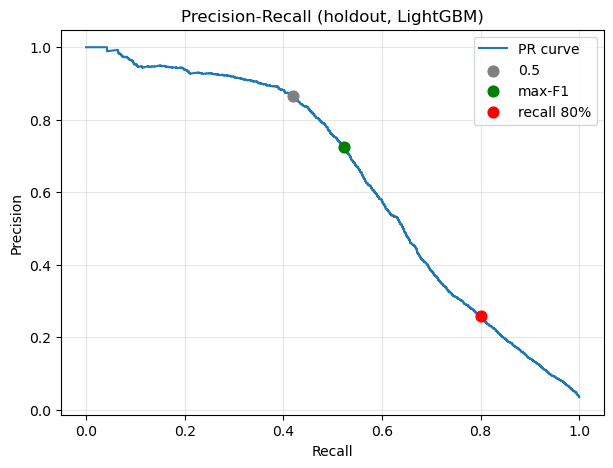

In [20]:
vp = pd.read_parquet(val_path)
y_h = vp["y"].values
p = vp["lgb"].values

prec, rec, thr = precision_recall_curve(y_h, p)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
thr_f1 = float(thr[int(np.nanargmax(f1s))])
target_recall = 0.80
mask = rec[:-1] >= target_recall
thr_rec = float(thr[mask].max()) if mask.any() else float(thr.min())

def report(name, t):
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_h, yhat).ravel()
    print(f"{name:16s} thr={t:.3f} | P={precision_score(y_h, yhat):.3f} "
          f"R={recall_score(y_h, yhat):.3f} F1={f1_score(y_h, yhat):.3f} | "
          f"поймано {tp}/{tp+fn} фрода, ложных {fp}")

report("baseline 0.5", 0.5)
report("max-F1", thr_f1)
report(f"recall>={target_recall:.0%}", thr_rec)

plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label="PR curve")
for t, lbl, clr in [(0.5, "0.5", "gray"), (thr_f1, "max-F1", "green"),
                    (thr_rec, f"recall {target_recall:.0%}", "red")]:
    yhat = (p >= t).astype(int)
    plt.scatter(recall_score(y_h, yhat), precision_score(y_h, yhat),
                color=clr, s=60, zorder=5, label=lbl)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (holdout, LightGBM)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Вывод

При пороге 0.5 модель помечает лишь часть мошеннических операций. Как инструмент для
упорядочивания операций по уровню риска она работает хорошо, но рабочий порог нужно выбирать
исходя из стоимости ошибок для бизнеса: цена пропущенного мошенничества против цены ложной
блокировки честной операции. Чем ниже порог, тем больше мошенничества мы ловим (выше полнота),
но тем больше и ложных срабатываний.

### Summary

At a threshold of 0.5 the model flags only part of the fraudulent transactions. As a tool for
ranking transactions by risk it works well, but the operating threshold should be chosen based
on the cost of mistakes for the business: the cost of a missed fraud versus the cost of
falsely blocking a legitimate transaction. The lower the threshold, the more fraud we catch
(higher recall), but the more false alarms we get too.

## Итоги ноутбука 02 / Notebook 02 — conclusions

Что сделали в этом ноутбуке:
- Сравнили четыре базовые модели — три модели градиентного бустинга заметно обогнали
  логистическую регрессию (зависимости в данных нелинейные).
- Подобрали гиперпараметры трёх моделей (Optuna): качество выросло у всех, а итоговые
  результаты сблизились.
- Переобучили лучшие модели на всех данных и сохранили для предсказаний в ноутбуке 03.
- Проверили объединение моделей: на отложенной выборке прироста почти нет.
- Посмотрели важность признаков (SHAP) и разобрали выбор рабочего порога.

Результат на Kaggle (ROC-AUC, Public / Private):

| Сабмишен | Public | Private |
|---|---|---|
| Одиночный LightGBM (с подобранными параметрами) | 0.949379 | 0.919059 |
| Объединение LightGBM + XGBoost | 0.948949 | **0.919338** |

Лучший результат на private дало **объединение двух моделей** (LightGBM + XGBoost). Но разница
с одиночной моделью мизерная (0.919338 против 0.919059), а на public выигрывает как раз
одиночный LightGBM. Поэтому в качестве итоговой модели мы выбираем **одну настроенную модель —
LightGBM**: она проще, быстрее и стабильнее в работе, а объединение моделей практически ничего
не добавляет.

## Notebook 02 — conclusions

What we did in this notebook:
- Compared four baseline models — the three gradient boosting models clearly beat logistic
  regression (the relationships in the data are non-linear).
- Tuned the hyperparameters of the three models (Optuna): all of them improved, and the final
  results converged.
- Retrained the best models on all the data and saved them for predictions in notebook 03.
- Checked combining the models: on the held-out set there is almost no gain.
- Looked at feature importance (SHAP) and discussed how to choose the operating threshold.

Results on Kaggle (ROC-AUC, Public / Private):

| Submission | Public | Private |
|---|---|---|
| Single LightGBM (tuned) | 0.949379 | 0.919059 |
| LightGBM + XGBoost combined | 0.948949 | **0.919338** |

The best private result came from **combining the two models** (LightGBM + XGBoost). But the
difference from the single model is tiny (0.919338 vs 0.919059), and on the public board the
single LightGBM actually wins. So as the final model we choose **a single tuned model —
LightGBM**: it is simpler, faster and more stable in production, while combining models adds
almost nothing.